<a href="https://colab.research.google.com/github/devincriniti/DSC_110/blob/main/DSC110_MODEL_EVALUATION_IN_CLASS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## here we are importing the panda library, matplot library, scikit learn model,
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
## here we are uploading the train and test libraries we will use
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#here we are making it more compatabile with sci kit learn
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [4]:
## here we are creating an "object for the model" and adding the random state to make the results more producable, we are the using random forest.fit to detect patterns between the input data and output data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
## here we are testing how our model performs, and having it show us the classification report and auc score
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC-ROC: 0.7488


In [7]:
y_pred_03 = (y_prob >= 0.3).astype(int)

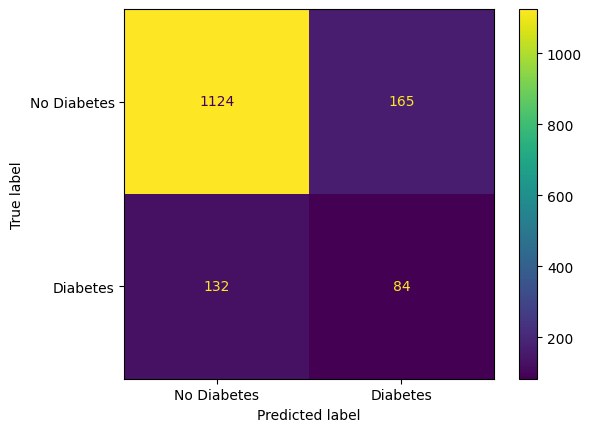

In [8]:


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show()


In [10]:
y_pred_07 = (y_prob >= 0.7).astype(int)


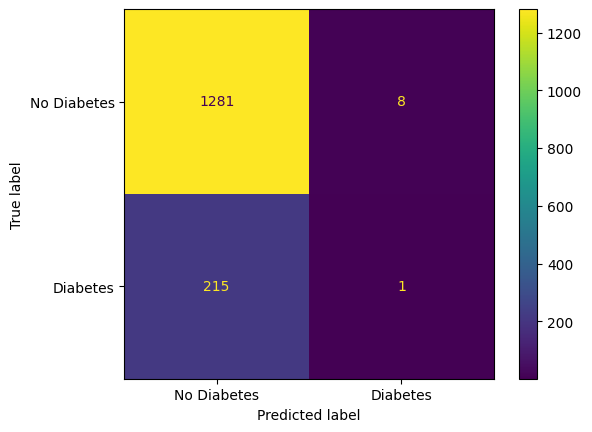

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_07, display_labels=['No Diabetes', 'Diabetes'])
plt.show()
